In [1]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
from tqdm import tqdm
from pathlib import Path
import os

from pathlib import Path

# ── Project paths ─────────────────────────────────────────────
PROJECT_ROOT = Path(r"D:\ANN\ANN_Project\working")
DATA_ROOT   = PROJECT_ROOT / "ami"                # folder containing per-meeting subdirs
MANUAL_PATH = PROJECT_ROOT / "ami_public_manual_1.6.2"   # extracted manual annotations folder
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "processed_data"  # intermediate files
SAVE_DIR    = PROJECT_ROOT / "outputs" / "saved"           # embeddings, models, results

for d in [OUTPUT_ROOT, SAVE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Paths configured.")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT   :", DATA_ROOT)
print("MANUAL_PATH :", MANUAL_PATH)
print("OUTPUT_ROOT :", OUTPUT_ROOT)
print("SAVE_DIR    :", SAVE_DIR)

print("\nExists check:")
print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())
print("DATA_ROOT exists   :", DATA_ROOT.exists())
print("MANUAL_PATH exists :", MANUAL_PATH.exists())
print("OUTPUT_ROOT exists :", OUTPUT_ROOT.exists())
print("SAVE_DIR exists    :", SAVE_DIR.exists())


c:\Users\LOQ\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Paths configured.
PROJECT_ROOT: D:\ANN\ANN_Project\working
DATA_ROOT   : D:\ANN\ANN_Project\working\ami
MANUAL_PATH : D:\ANN\ANN_Project\working\ami_public_manual_1.6.2
OUTPUT_ROOT : D:\ANN\ANN_Project\working\outputs\processed_data
SAVE_DIR    : D:\ANN\ANN_Project\working\outputs\saved

Exists check:
PROJECT_ROOT exists: True
DATA_ROOT exists   : True
MANUAL_PATH exists : True
OUTPUT_ROOT exists : True
SAVE_DIR exists    : True


# Meetings Retrieval

Goal:
- Load AMI dataset
- Prepare paths
- List all meetings

In [2]:
# ── Optional: extract AMI_Corpus.zip if not already extracted ───────────────
import zipfile

AMI_ZIP     = Path("data/AMI_Corpus.zip")
MANUAL_ZIP  = Path("data/ami_public_manual_1.6.2.zip")

if AMI_ZIP.exists() and not DATA_ROOT.exists():
    DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(AMI_ZIP, 'r') as z:
        z.extractall(DATA_ROOT.parent.parent)
    print("AMI corpus extracted.")

if MANUAL_ZIP.exists() and not MANUAL_PATH.exists():
    MANUAL_PATH.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MANUAL_ZIP, 'r') as z:
        z.extractall(MANUAL_PATH)
    print("AMI manual extracted.")

print("Data dirs ready.")


Data dirs ready.


In [3]:
meetings = [f for f in DATA_ROOT.iterdir() if f.is_dir()]
print("Meetings found:", len(meetings))
print([m.name for m in meetings])


Meetings found: 30
['EN2001a', 'EN2001b', 'EN2001d', 'EN2001e', 'EN2002a', 'EN2002b', 'EN2002c', 'EN2002d', 'EN2003a', 'EN2004a', 'EN2005a', 'EN2006a', 'EN2006b', 'EN2009b', 'EN2009c', 'EN2009d', 'ES2002a', 'ES2002b', 'ES2002c', 'ES2002d', 'ES2003a', 'ES2003b', 'ES2003c', 'ES2003d', 'ES2004a', 'ES2004b', 'ES2004c', 'ES2004d', 'ES2005a', 'ES2005b']


# Preprocessing

In [4]:
def load_audio(meeting_path, target_sr=16000):
    audio_dir = meeting_path / "audio"
    if not audio_dir.exists():
        return None, None, None

    wav_files = list(audio_dir.glob("*.wav"))
    if not wav_files:
        return None, None, None

    tracks = {}
    for f in wav_files:
        for channel in range(5):
            if f"Headset-{channel}" in f.name:
                audio, sr = librosa.load(f, sr=target_sr, mono=True)
                tracks[f"Headset-{channel}"] = audio
                break

    if not tracks:
        return None, None, None

    print(f"  {meeting_path.name}: found {list(tracks.keys())}")

    min_len = min(len(a) for a in tracks.values())
    tracks  = {s: a[:min_len] for s, a in tracks.items()}

    mixed = np.sum(list(tracks.values()), axis=0)
    mixed = mixed / (np.max(np.abs(mixed)) + 1e-8)
    return mixed, tracks, target_sr


# Sliding Window Segmentation

Split audio into fixed **30-second windows** with a **15-second hop**.

This gives **50% overlap**:
- Window 0: 0s → 30s
- Window 1: 15s → 45s
- Window 2: 30s → 60s

Why this is better for HuBERT embeddings:
- 30 seconds gives HuBERT more speech context than 5 seconds.
- 15 seconds overlap reduces the chance of losing speech at window boundaries.
- 50% overlap is a balanced choice: enough continuity without creating too many duplicate windows.

(VAD was dropped — it misclassified low-frequency speech as silence.)


In [5]:
# Window settings used across the notebook
WINDOW_SEC = 30.0
HOP_SEC = 15.0
OVERLAP_SEC = WINDOW_SEC - HOP_SEC

print(f"Window length: {WINDOW_SEC:.0f}s")
print(f"Hop length:    {HOP_SEC:.0f}s")
print(f"Overlap:       {OVERLAP_SEC:.0f}s ({OVERLAP_SEC / WINDOW_SEC:.0%})")


def sliding_windows(audio, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    """
    Split audio into overlapping windows.

    Default setup:
        window_sec = 30 seconds
        hop_sec    = 15 seconds
        overlap    = 15 seconds = 50%

    The function keeps the final tail of the audio by adding one last
    full-length window ending at the final sample when needed.
    """
    window_size = int(window_sec * sr)
    hop_size = int(hop_sec * sr)

    if window_size <= 0:
        raise ValueError("window_sec must be positive")
    if hop_size <= 0:
        raise ValueError("hop_sec must be positive")
    if hop_size > window_size:
        raise ValueError("hop_sec should be <= window_sec to keep overlap")

    windows = []
    n = len(audio)

    if n == 0:
        return windows

    # If the audio is shorter than one window, pad it to one full window.
    if n < window_size:
        padded = np.pad(audio, (0, window_size - n), mode='constant')
        windows.append({
            "start_time": 0.0,
            "end_time": n / sr,
            "audio": padded,
            "is_padded": True
        })
        return windows

    # Normal hop-aligned windows.
    for start in range(0, n - window_size + 1, hop_size):
        end = start + window_size
        windows.append({
            "start_time": start / sr,
            "end_time": end / sr,
            "audio": audio[start:end],
            "is_padded": False
        })

    # Preserve the final tail if the last hop-aligned window does not reach the end.
    last_end_sample = int(windows[-1]["end_time"] * sr)
    if last_end_sample < n:
        start = n - window_size
        end = n
        # Avoid duplicating the last window if it already starts at the same point.
        if start > int(windows[-1]["start_time"] * sr):
            windows.append({
                "start_time": start / sr,
                "end_time": end / sr,
                "audio": audio[start:end],
                "is_padded": False
            })

    return windows


def compute_rms(audio):
    return np.sqrt(np.mean(audio ** 2))


Window length: 30s
Hop length:    15s
Overlap:       15s (50%)


In [6]:
# Quick sanity check on one meeting
meeting = meetings[5]
mixed, tracks, sr = load_audio(meeting)
print("Meeting:", meeting.name)

windows = sliding_windows(mixed, sr)
print("Total windows:", len(windows))
print(f"Window setup: {WINDOW_SEC:.0f}s window, {HOP_SEC:.0f}s hop, {OVERLAP_SEC:.0f}s overlap")

for i in range(min(5, len(windows))):
    w = windows[i]
    print(f"Window {i}: {w['start_time']:.2f}s → {w['end_time']:.2f}s")


  EN2002b: found ['Headset-0', 'Headset-1', 'Headset-2', 'Headset-3']
Meeting: EN2002b
Total windows: 119
Window setup: 30s window, 15s hop, 15s overlap
Window 0: 0.00s → 30.00s
Window 1: 15.00s → 45.00s
Window 2: 30.00s → 60.00s
Window 3: 45.00s → 75.00s
Window 4: 60.00s → 90.00s


RMS stats:
  Min: 0.001163968
  Max: 0.056430966
  Mean: 0.015272456
  Median: 0.011590757


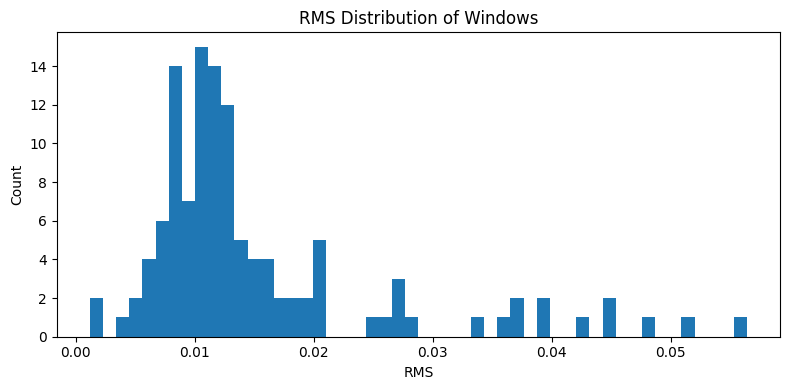

In [7]:
rms_values = np.array([compute_rms(w['audio']) for w in windows])
print("RMS stats:")
print("  Min:",    rms_values.min())
print("  Max:",    rms_values.max())
print("  Mean:",   rms_values.mean())
print("  Median:", np.median(rms_values))

plt.figure(figsize=(8, 4))
plt.hist(rms_values, bins=50)
plt.title("RMS Distribution of Windows")
plt.xlabel("RMS"); plt.ylabel("Count")
plt.tight_layout(); plt.show()


In [8]:
RMS_SILENCE_THRESHOLD = 0.00061

for w in windows:
    w['rms']       = compute_rms(w['audio'])
    w['is_silent'] = w['rms'] < RMS_SILENCE_THRESHOLD

silent_count = sum(w['is_silent'] for w in windows)
print("Total windows:", len(windows))
print("Silent windows:", silent_count)
print("Silent %:", silent_count / len(windows) * 100)


Total windows: 119
Silent windows: 0
Silent %: 0.0


## Save Preprocessed Audio Windows

In [9]:
audio_dir = OUTPUT_ROOT / f'windows_audio_{int(WINDOW_SEC)}s_{int(HOP_SEC)}s_hop'
audio_dir.mkdir(exist_ok=True)

rows = []

for meeting in tqdm(meetings):
    mixed, tracks, sr = load_audio(meeting)
    if mixed is None:
        continue

    windows = sliding_windows(mixed, sr, window_sec=WINDOW_SEC, hop_sec=HOP_SEC)

    for i, w in enumerate(windows):
        chunk = w['audio']
        rms = compute_rms(chunk)

        file_name = f"{meeting.name}_w{i}_{int(WINDOW_SEC)}s.npy"
        file_path = audio_dir / file_name
        np.save(file_path, chunk)

        rows.append({
            'meeting': meeting.name,
            'window_idx': i,
            'start_time': w['start_time'],
            'end_time': w['end_time'],
            'window_sec': WINDOW_SEC,
            'hop_sec': HOP_SEC,
            'overlap_sec': OVERLAP_SEC,
            'is_padded': bool(w.get('is_padded', False)),
            'rms': rms,
            'is_silent': rms < RMS_SILENCE_THRESHOLD,
            'audio_path': str(file_path)
        })

df_audio = pd.DataFrame(rows)
metadata_path = OUTPUT_ROOT / f'windows_metadata_{int(WINDOW_SEC)}s_{int(HOP_SEC)}s_hop.csv'
df_audio.to_csv(metadata_path, index=False)

# Keep the original filename too, so the rest of the notebook can continue normally.
df_audio.to_csv(OUTPUT_ROOT / 'windows_metadata.csv', index=False)

print("Window setup:", f"{WINDOW_SEC:.0f}s window / {HOP_SEC:.0f}s hop / {OVERLAP_SEC:.0f}s overlap")
print("Total windows saved:", len(df_audio))
print("Metadata saved to:", metadata_path)
print(df_audio.head())


  0%|          | 0/30 [00:00<?, ?it/s]

  EN2001a: found ['Headset-0', 'Headset-1', 'Headset-2', 'Headset-3', 'Headset-4']


  3%|▎         | 1/30 [00:07<03:24,  7.03s/it]

  EN2001b: found ['Headset-0', 'Headset-1', 'Headset-2', 'Headset-3']


  7%|▋         | 2/30 [00:11<02:32,  5.44s/it]

...

  ES2005a: found ['Headset-0', 'Headset-1', 'Headset-2', 'Headset-3']


 97%|█████████▋| 29/30 [02:51<00:02,  2.22s/it]

  ES2005b: found ['Headset-0', 'Headset-1', 'Headset-2', 'Headset-3']


100%|██████████| 30/30 [03:34<00:00,  7.14s/it]

Window setup: 30s window / 15s hop / 15s overlap
Total windows saved: 5398
Metadata saved to: D:\ANN\ANN_Project\working\outputs\processed_data\windows_metadata_30s_15s_hop.csv
   meeting  window_idx  start_time  end_time  window_sec  hop_sec  \
0  EN2001a           0         0.0      30.0        30.0     15.0   
1  EN2001a           1        15.0      45.0        30.0     15.0   
2  EN2001a           2        30.0      60.0        30.0     15.0   
3  EN2001a           3        45.0      75.0        30.0     15.0   
4  EN2001a           4        60.0      90.0        30.0     15.0   

   overlap_sec  is_padded       rms  is_silent  \
0         15.0      False  0.010562      False   
1         15.0      False  0.010498      False   
2         15.0      False  0.010080      False   
3         15.0      False  0.015263      False   
4         15.0      False  0.014966      False   

                                          audio_path  
0  D:\ANN\ANN_Project\working\outputs\processed_d...

# Feature Extraction: Log-Mel Spectrogram

Log-mel features are saved for visualisation purposes.
HuBERT operates on raw waveforms and does not use these features.

Mel shape: (128, 938)


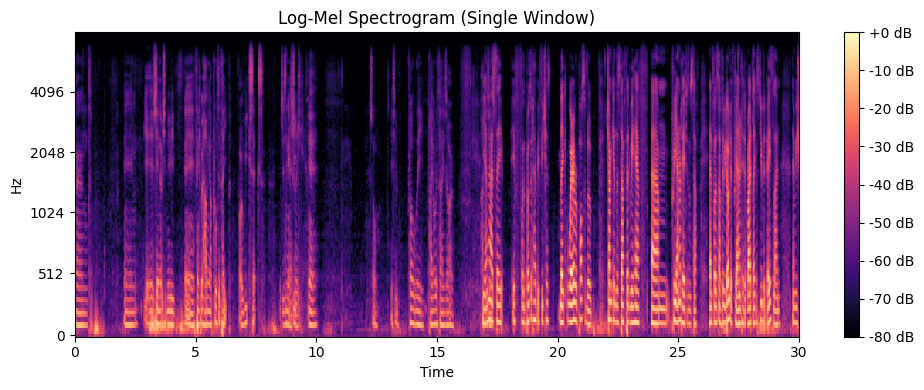

In [10]:
def extract_log_mel(audio, sr=16000, n_mels=128):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr,
                                          n_mels=n_mels, hop_length=512)
    return librosa.power_to_db(mel, ref=np.max)

# Visualise one sample
sample = df_audio.iloc[2]
audio  = np.load(sample['audio_path'])
mel    = extract_log_mel(audio)
print("Mel shape:", mel.shape)

plt.figure(figsize=(10, 4))
librosa.display.specshow(mel, sr=16000, hop_length=512,
                          x_axis='time', y_axis='mel')
plt.colorbar(format="%+2.0f dB")
plt.title("Log-Mel Spectrogram (Single Window)")
plt.tight_layout(); plt.show()


In [11]:
logmel_dir = OUTPUT_ROOT / f'logmel_features_{int(WINDOW_SEC)}s_{int(HOP_SEC)}s_hop'
logmel_dir.mkdir(exist_ok=True)
logmel_rows = []

for i, row in tqdm(df_audio.iterrows(), total=len(df_audio)):
    audio = np.load(row['audio_path'])
    log_mel = extract_log_mel(audio)
    fname = row["meeting"] + f'_w{row["window_idx"]}_{int(WINDOW_SEC)}s.npy'
    fpath = logmel_dir / fname
    np.save(fpath, log_mel)
    logmel_rows.append({
        'meeting': row['meeting'],
        'window_idx': row['window_idx'],
        'start_time': row['start_time'],
        'end_time': row['end_time'],
        'window_sec': row.get('window_sec', WINDOW_SEC),
        'hop_sec': row.get('hop_sec', HOP_SEC),
        'overlap_sec': row.get('overlap_sec', OVERLAP_SEC),
        'rms': row['rms'],
        'is_silent': row['is_silent'],
        'feature_path': str(fpath)
    })

df_logmel = pd.DataFrame(logmel_rows)
logmel_metadata_path = OUTPUT_ROOT / f'logmel_metadata_{int(WINDOW_SEC)}s_{int(HOP_SEC)}s_hop.csv'
df_logmel.to_csv(logmel_metadata_path, index=False)

# Keep the original filename too, so the rest of the notebook can continue normally.
df_logmel.to_csv(OUTPUT_ROOT / 'logmel_metadata.csv', index=False)

print("Saved Log-Mel windows:", len(df_logmel))
print("Log-Mel metadata saved to:", logmel_metadata_path)


100%|██████████| 5398/5398 [03:38<00:00, 24.72it/s]

Saved Log-Mel windows: 5398
Log-Mel metadata saved to: D:\ANN\ANN_Project\working\outputs\processed_data\logmel_metadata_30s_15s_hop.csv


# Speaker Label Assignment

Parse AMI manual segment XML files to assign a dominant speaker label
to each audio window based on speech overlap.

In [12]:
import xml.etree.ElementTree as ET

segments_dir = MANUAL_PATH / "segments"
seg_files = list(segments_dir.glob("*.xml"))

print(f"Total segment files: {len(seg_files)}")

your_meetings = [
    "EN2001a",
    "EN2001b",
    "EN2001d",
    "EN2001e",
    "EN2002a",
    "EN2002b",
    "EN2002c",
    "EN2002d",
    "EN2003a",
    "EN2004a",
    "EN2005a",
    "EN2006a",
    "EN2006b",
    "EN2009b",
    "EN2009c",
    "EN2009d",
    "ES2002a",
    "ES2002b",
    "ES2002c",
    "ES2002d",
    "ES2003a",
    "ES2003b",
    "ES2003c",
    "ES2003d",
    "ES2004a",
    "ES2004b",
    "ES2004c",
    "ES2004d",
    "ES2005a",
    "ES2005b"
]

matched = [
    f for f in seg_files
    if any(m in f.name for m in your_meetings)
]

print(f"Matched segment files: {len(matched)}")

matched_meetings = set()

for f in matched:
    for m in your_meetings:
        if m in f.name:
            matched_meetings.add(m)

missing_meetings = sorted(set(your_meetings) - matched_meetings)

print("Meetings with XML:", len(matched_meetings))
print("Missing meetings:", len(missing_meetings))
print("Missing meetings list:", missing_meetings)

Total segment files: 687
Matched segment files: 123
Meetings with XML: 30
Missing meetings: 0
Missing meetings list: []


In [13]:
def parse_segments(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    segments = []
    for seg in root.findall('segment'):
        start = float(seg.attrib['transcriber_start'])
        end   = float(seg.attrib['transcriber_end'])
        segments.append((start, end))
    return segments

def get_dominant_speaker(window_start, window_end, speaker_segments):
    best_speaker = 'silence'
    best_overlap = 0.0
    for speaker, segments in speaker_segments.items():
        overlap = sum(
            max(0, min(window_end, seg_end) - max(window_start, seg_start))
            for seg_start, seg_end in segments
        )
        if overlap > best_overlap:
            best_overlap = overlap
            best_speaker = speaker
    return best_speaker, best_overlap


In [14]:
from sklearn.preprocessing import LabelEncoder

# df_audio carries audio_path; df_logmel carries feature_path
# Merge so labeled df has both
df_logmel_audio = df_logmel.merge(
    df_audio[['meeting', 'window_idx', 'audio_path']],
    on=['meeting', 'window_idx'],
    how='left'
)

rows_labeled = []

for _, row in tqdm(df_logmel_audio.iterrows(), total=len(df_logmel_audio)):
    meeting           = row['meeting']
    meeting_seg_files = [f for f in matched if meeting in f.name]

    speaker_segments = {}
    for f in meeting_seg_files:
        speaker = f.name.split('.')[1]
        speaker_segments[speaker] = parse_segments(f)

    dominant_speaker, overlap = get_dominant_speaker(
        row['start_time'], row['end_time'], speaker_segments
    )

    rows_labeled.append({
        'meeting':        meeting,
        'window_idx':     row['window_idx'],
        'start_time':     row['start_time'],
        'end_time':       row['end_time'],
        'rms':            row['rms'],
        'is_silent':      int(row['is_silent']),
        'audio_path':     row['audio_path'],     # raw waveform path for HuBERT
        'feature_path':   row['feature_path'],   # log-mel path (visualisation only)
        'speaker_id':     meeting + '.' + dominant_speaker,
        'speech_overlap': overlap
    })

df_labeled = pd.DataFrame(rows_labeled)

le = LabelEncoder()
df_labeled['speaker_label'] = le.fit_transform(df_labeled['speaker_id'])
speaker_classes = list(le.classes_)

pd.Series(speaker_classes).to_csv(
    OUTPUT_ROOT / 'speaker_classes.csv', index=True, header=['speaker_id']
)
df_labeled.to_csv(OUTPUT_ROOT / 'labeled_metadata.csv', index=False)

print("Total labeled windows:", len(df_labeled))
print("Columns:", df_labeled.columns.tolist())
print("Unique speaker IDs:", len(speaker_classes))
print("Silence windows:", df_labeled["speaker_id"].str.contains("silence").sum())


100%|██████████| 5398/5398 [00:24<00:00, 221.46it/s]


Total labeled windows: 5398
Columns: ['meeting', 'window_idx', 'start_time', 'end_time', 'rms', 'is_silent', 'audio_path', 'feature_path', 'speaker_id', 'speech_overlap', 'speaker_label']
Unique speaker IDs: 135
Silence windows: 125


In [16]:
print("Total windows:", len(df_labeled))
print("Unique speaker IDs:", df_labeled["speaker_id"].nunique())
print("XML silence labels:", df_labeled["speaker_id"].astype(str).str.contains("silence", case=False, na=False).sum())
print(df_labeled["speaker_id"].value_counts().head(20))

Total windows: 5398
Unique speaker IDs: 135
XML silence labels: 125
speaker_id
EN2001a.E    228
EN2004a.B    176
EN2001e.B    160
EN2009d.B    151
EN2005a.D    141
EN2006a.B    139
EN2001b.B    135
EN2001d.B    131
EN2006b.B    127
EN2003a.A    121
EN2005a.B    117
EN2009d.A    105
EN2005a.A     90
EN2009c.B     86
EN2002c.B     81
EN2006a.C     73
ES2003d.B     69
ES2003b.B     66
EN2009c.C     65
EN2002c.C     63
Name: count, dtype: int64


# HuBERT Embedding Extraction — Fixed Version

Raw audio windows are passed through `facebook/hubert-base-ls960` as a **frozen** feature extractor.

Fixes in this version:
- The untrained/random projector was removed.
- HuBERT embeddings are now used directly as **768-dimensional** vectors.
- Padding is handled by the Hugging Face feature extractor.
- `attention_mask` is passed to HuBERT and used during mean pooling, so padded samples are not averaged as real audio.
- Embeddings are L2-normalized before saving.

No clustering is added in this notebook section.

Windowing update in this version:
- Audio windows are now **30 seconds** long.
- Hop length is **15 seconds**, giving **50% overlap**.
- HuBERT batch size is reduced because 30-second windows use more GPU/CPU memory.


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
from transformers import HubertModel, Wav2Vec2FeatureExtractor

# Reproducibility: useful for any later evaluation / sanity checks.
# HuBERT itself is frozen here, so the main extraction is deterministic in eval mode.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

MODEL_NAME = "facebook/hubert-base-ls960"
feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(MODEL_NAME)
hubert = HubertModel.from_pretrained(MODEL_NAME).to(device)

# Freeze HuBERT: we only use it as a pre-trained feature extractor.
hubert.eval()
for p in hubert.parameters():
    p.requires_grad = False

print("HuBERT loaded — hidden size:", hubert.config.hidden_size)  # 768
print("Random projector: removed")


Device: cpu


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

c:\Users\LOQ\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LOQ\.cache\huggingface\hub\models--facebook--hubert-base-ls960. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HuBERT loaded — hidden size: 768
Random projector: removed


In [ ]:
class HuBERTEncoder(nn.Module):
    """
    Frozen HuBERT encoder that returns direct HuBERT embeddings.

    Input:
        input_values:    (B, T) raw waveforms at 16 kHz
        attention_mask:  (B, T) mask from the feature extractor

    Output:
        (B, 768) L2-normalized embeddings
    """
    def __init__(self, hubert_model):
        super().__init__()
        self.hubert = hubert_model

    def _masked_mean_pool(self, hidden, attention_mask=None):
        """Mean-pool HuBERT frames while ignoring padded regions."""
        if attention_mask is None:
            return hidden.mean(dim=1)

        # Convert waveform-level mask to HuBERT feature-frame mask.
        # HuBERT downsamples the raw waveform, so mask length must match hidden frames.
        if hasattr(self.hubert, "_get_feature_vector_attention_mask"):
            frame_mask = self.hubert._get_feature_vector_attention_mask(
                hidden.shape[1],
                attention_mask
            )
        else:
            # Fallback for compatibility with different transformers versions.
            frame_mask = torch.nn.functional.interpolate(
                attention_mask[:, None].float(),
                size=hidden.shape[1],
                mode="nearest"
            ).squeeze(1).bool()

        frame_mask = frame_mask.to(hidden.device).unsqueeze(-1).type_as(hidden)
        summed = (hidden * frame_mask).sum(dim=1)
        counts = frame_mask.sum(dim=1).clamp(min=1e-6)
        return summed / counts

    def forward(self, input_values, attention_mask=None):
        with torch.no_grad():
            outputs = self.hubert(
                input_values=input_values,
                attention_mask=attention_mask
            )
            hidden = outputs.last_hidden_state  # (B, frames, 768)

        pooled = self._masked_mean_pool(hidden, attention_mask)  # (B, 768)
        return nn.functional.normalize(pooled, p=2, dim=1)       # (B, 768)

hubert_encoder = HuBERTEncoder(hubert).to(device)
hubert_encoder.eval()

# Sanity check
sample_rate = 16000
dummy = torch.randn(2, sample_rate * 5).to(device)
dummy_attention_mask = torch.ones(dummy.shape, dtype=torch.long, device=device)

with torch.no_grad():
    out = hubert_encoder(dummy, attention_mask=dummy_attention_mask)

print("Output shape:", out.shape)                 # expected: (2, 768)
print("Embedding dimension:", out.shape[1])       # expected: 768
print("Mean L2 norm:", out.norm(dim=1).mean().item())  # expected: ~1.0


Output shape: torch.Size([2, 768])
Embedding dimension: 768
Mean L2 norm: 1.0


In [ ]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# This file is produced by the speaker-label assignment step above.
df_all = pd.read_csv(OUTPUT_ROOT / 'labeled_metadata.csv')

# 30-second windows are much longer than the old 5-second windows.
# Use a smaller batch size to avoid GPU/CPU memory problems.
BATCH_SIZE = 2   # if GPU OOM, reduce to 1; if memory is enough, try 4
SR = 16000

hubert_encoder.eval()
all_embeddings = []
audio_paths = df_all['audio_path'].astype(str).tolist()

# Validate paths early to avoid silent failures during a long extraction run.
missing_paths = [p for p in audio_paths if not Path(p).exists()]
if missing_paths:
    raise FileNotFoundError(
        f"Found {len(missing_paths)} missing audio files. Example: {missing_paths[0]}"
    )

for i in tqdm(range(0, len(audio_paths), BATCH_SIZE), desc='HuBERT direct 768-d extraction'):
    batch_paths = audio_paths[i : i + BATCH_SIZE]
    batch_wavs = [np.load(p).astype(np.float32) for p in batch_paths]

    # Correct padding + attention mask are created here.
    # This replaces manual padding and prevents padded samples from being pooled as real audio.
    inputs = feature_extractor(
        batch_wavs,
        sampling_rate=SR,
        return_tensors='pt',
        padding=True,
        return_attention_mask=True
    )

    input_values = inputs.input_values.to(device)
    attention_mask = inputs.attention_mask.to(device)

    with torch.no_grad():
        embs = hubert_encoder(
            input_values=input_values,
            attention_mask=attention_mask
        ).cpu().numpy()

    all_embeddings.append(embs)

all_embeddings = np.vstack(all_embeddings)
print("Embeddings shape:", all_embeddings.shape)  # expected: (num_windows, 768)

assert all_embeddings.shape[0] == len(df_all), "Number of embeddings must match metadata rows."
assert all_embeddings.shape[1] == hubert.config.hidden_size, "Expected direct HuBERT 768-d embeddings."

# Save with clear filenames so they are not confused with the old 5s / 256-d projector output.
embeddings_path = SAVE_DIR / 'hubert_embeddings_768_direct_30s_15s_hop.npy'
metadata_path = SAVE_DIR / 'hubert_embeddings_768_direct_30s_15s_hop_metadata.csv'

np.save(embeddings_path, all_embeddings)
df_all.to_csv(metadata_path, index=False)

print("Saved embeddings to:", embeddings_path)
print("Saved metadata to:", metadata_path)


HuBERT direct 768-d extraction:   0%|          | 0/2699 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

HuBERT direct 768-d extraction: 100%|██████████| 2699/2699 [3:04:55<00:00,  4.11s/it]  


Embeddings shape: (5398, 768)
Saved embeddings to: D:\ANN\ANN_Project\working\outputs\saved\hubert_embeddings_768_direct_30s_15s_hop.npy
Saved metadata to: D:\ANN\ANN_Project\working\outputs\saved\hubert_embeddings_768_direct_30s_15s_hop_metadata.csv


In [ ]:
X = np.load(SAVE_DIR / "hubert_embeddings_768_direct_30s_15s_hop.npy")
meta = pd.read_csv(SAVE_DIR / "hubert_embeddings_768_direct_30s_15s_hop_metadata.csv")

print("Embeddings:", X.shape)
print("Metadata:", meta.shape)
print(meta.head())

Embeddings: (5398, 768)
Metadata: (5398, 11)
   meeting  window_idx  start_time  end_time       rms  is_silent  \
0  EN2001a           0         0.0      30.0  0.010562          0   
1  EN2001a           1        15.0      45.0  0.010498          0   
2  EN2001a           2        30.0      60.0  0.010080          0   
3  EN2001a           3        45.0      75.0  0.015263          0   
4  EN2001a           4        60.0      90.0  0.014966          0   

                                          audio_path  \
0  D:\ANN\ANN_Project\working\outputs\processed_d...   
1  D:\ANN\ANN_Project\working\outputs\processed_d...   
2  D:\ANN\ANN_Project\working\outputs\processed_d...   
3  D:\ANN\ANN_Project\working\outputs\processed_d...   
4  D:\ANN\ANN_Project\working\outputs\processed_d...   

                                        feature_path speaker_id  \
0  D:\ANN\ANN_Project\working\outputs\processed_d...  EN2001a.A   
1  D:\ANN\ANN_Project\working\outputs\processed_d...  EN2001a.A   
2 

## Final Evaluation Setup

From this point onward, windows labelled as XML `silence` are removed from training and evaluation. These windows do not have a clear dominant speaker, so removing them makes the speaker-classification and clustering comparison cleaner. HuBERT embeddings are reused from the saved `.npy` file; they are not re-extracted.


In [ ]:
# ============================================================
# Temporal Transformer Encoder on saved HuBERT embeddings
# Correct fair setup:
# 1) Load HuBERT embeddings
# 2) Fixed grouped train/val/test split
# 3) HuBERT baseline accuracy
# 4) Train Transformer only on train
# 5) Use val for early stopping
# 6) Evaluate both HuBERT and Transformer on same test
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ------------------------------------------------------------
# 1) Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ------------------------------------------------------------
# 2) Load saved HuBERT embeddings and metadata
# ------------------------------------------------------------
emb_path = SAVE_DIR / "hubert_embeddings_768_direct_30s_15s_hop.npy"
meta_path = SAVE_DIR / "hubert_embeddings_768_direct_30s_15s_hop_metadata.csv"

X = np.load(emb_path).astype(np.float32)
meta = pd.read_csv(meta_path)

print("Loaded embeddings:", X.shape)
print("Loaded metadata:", meta.shape)

assert len(X) == len(meta), "Embeddings and metadata length mismatch!"

# ------------------------------------------------------------
# Remove windows without a valid dominant speaker from XML
# These rows are not useful for speaker identity evaluation.
# HuBERT embeddings are NOT re-extracted; we only filter X/meta here.
# ------------------------------------------------------------
xml_silence_mask = meta["speaker_id"].astype(str).str.contains(
    "silence", case=False, na=False
)

print("XML silence windows before removal:", int(xml_silence_mask.sum()))

X = X[~xml_silence_mask.values]
meta = meta[~xml_silence_mask].reset_index(drop=True)

print("After removing XML silence labels:")
print("Embeddings:", X.shape)
print("Metadata:", meta.shape)
print("Remaining XML silence labels:",
      int(meta["speaker_id"].astype(str).str.contains("silence", case=False, na=False).sum()))

# ------------------------------------------------------------
# 3) Clean/filter data
# ------------------------------------------------------------

# Remove silent windows
mask = meta["is_silent"].values == 0
X = X[mask]
meta = meta[mask].reset_index(drop=True)

# Remove missing speaker labels
mask = meta["speaker_label"].notna().values
X = X[mask]
meta = meta[mask].reset_index(drop=True)

meta["speaker_label"] = meta["speaker_label"].astype(int)

# Remove very rare speakers for stable training
MIN_SAMPLES_PER_SPEAKER = 5

counts = meta["speaker_label"].value_counts()
valid_speakers = counts[counts >= MIN_SAMPLES_PER_SPEAKER].index

mask = meta["speaker_label"].isin(valid_speakers).values
X = X[mask]
meta = meta[mask].reset_index(drop=True)

# Sort by meeting and time
sort_idx = meta.sort_values(["meeting", "start_time"]).index.values
X = X[sort_idx]
meta = meta.iloc[sort_idx].reset_index(drop=True)

# Remap labels to 0..num_classes-1
original_labels = sorted(meta["speaker_label"].unique())
label_to_new = {old: new for new, old in enumerate(original_labels)}
new_to_label = {new: old for old, new in label_to_new.items()}

meta["speaker_label_original"] = meta["speaker_label"]
meta["speaker_label"] = meta["speaker_label_original"].map(label_to_new).astype(int)

y = meta["speaker_label"].values
num_classes = len(np.unique(y))

print("After filtering:")
print("X:", X.shape)
print("Metadata:", meta.shape)
print("Number of speakers/classes:", num_classes)

# Save label mapping
label_map_df = (
    meta.groupby(["speaker_label", "speaker_label_original"])["speaker_id"]
    .first()
    .reset_index()
    .sort_values("speaker_label")
)

label_map_path = SAVE_DIR / "transformer_speaker_label_mapping.csv"
label_map_df.to_csv(label_map_path, index=False)

print("Saved label mapping to:", label_map_path)

# ------------------------------------------------------------
# 4) Fixed grouped train / validation / test split
# ------------------------------------------------------------
# Important:
# We split BEFORE building sequences to avoid overlap leakage.

GROUP_SECONDS = 300  # 5-minute groups

meta["eval_group"] = (
    meta["meeting"].astype(str)
    + "_block_"
    + (meta["start_time"] // GROUP_SECONDS).astype(int).astype(str)
)

groups = meta["eval_group"].values

# First split: train_val / test
splitter1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED
)

train_val_idx, test_idx = next(
    splitter1.split(X, y, groups=groups)
)

# Second split: train / validation
splitter2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=SEED
)

inner_train_idx, inner_val_idx = next(
    splitter2.split(
        X[train_val_idx],
        y[train_val_idx],
        groups=groups[train_val_idx]
    )
)

train_idx = train_val_idx[inner_train_idx]
val_idx = train_val_idx[inner_val_idx]

# For classification accuracy, validation/test labels must exist in train
train_classes = np.unique(y[train_idx])

val_idx = val_idx[np.isin(y[val_idx], train_classes)]
test_idx = test_idx[np.isin(y[test_idx], train_classes)]

print("\nFixed split:")
print("Train windows:", len(train_idx))
print("Validation windows:", len(val_idx))
print("Test windows:", len(test_idx))

print("Train/Test overlap:", len(np.intersect1d(train_idx, test_idx)))
print("Val/Test overlap:", len(np.intersect1d(val_idx, test_idx)))
print("Train/Val overlap:", len(np.intersect1d(train_idx, val_idx)))

In [ ]:
# ============================================================
# HuBERT baseline accuracy on the fixed grouped test split
# ============================================================

hubert_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED
    )
)

hubert_clf.fit(X[train_idx], y[train_idx])

y_pred_hubert = hubert_clf.predict(X[test_idx])

hubert_test_acc = accuracy_score(y[test_idx], y_pred_hubert)

print("=" * 60)
print("HuBERT Baseline Test Accuracy:", round(hubert_test_acc * 100, 2), "%")
print("=" * 60)
print(classification_report(y[test_idx], y_pred_hubert, zero_division=0))

In [ ]:
# ============================================================
# Build temporal sequences separately for train / val / test
# ============================================================

SEQ_LEN = 8
SEQ_STRIDE = 1

def build_sequences_from_indices(meta, y, allowed_indices, seq_len=8, stride=1):
    """
    Build sequences only inside the same eval_group.
    This prevents crossing train/val/test boundaries.
    """
    allowed_indices = set(allowed_indices)

    sequences = []
    sequence_labels = []

    for group_id, group_df in meta.groupby("eval_group"):
        group_df = group_df.sort_values("start_time")

        idxs = [idx for idx in group_df.index.values if idx in allowed_indices]

        if len(idxs) < seq_len:
            continue

        for start in range(0, len(idxs) - seq_len + 1, stride):
            seq_idx = np.array(idxs[start:start + seq_len], dtype=np.int64)

            sequences.append(seq_idx)
            sequence_labels.append(y[seq_idx])

    return np.array(sequences, dtype=np.int64), np.array(sequence_labels, dtype=np.int64)


train_sequences, train_sequence_labels = build_sequences_from_indices(
    meta, y, train_idx, seq_len=SEQ_LEN, stride=SEQ_STRIDE
)

val_sequences, val_sequence_labels = build_sequences_from_indices(
    meta, y, val_idx, seq_len=SEQ_LEN, stride=SEQ_STRIDE
)

test_sequences, test_sequence_labels = build_sequences_from_indices(
    meta, y, test_idx, seq_len=SEQ_LEN, stride=SEQ_STRIDE
)

print("Train sequences:", train_sequences.shape)
print("Validation sequences:", val_sequences.shape)
print("Test sequences:", test_sequences.shape)

if len(train_sequences) == 0:
    raise ValueError("No train sequences created. Reduce SEQ_LEN or increase GROUP_SECONDS.")

if len(val_sequences) == 0:
    raise ValueError("No validation sequences created. Reduce SEQ_LEN or increase GROUP_SECONDS.")

if len(test_sequences) == 0:
    raise ValueError("No test sequences created. Reduce SEQ_LEN or increase GROUP_SECONDS.")

In [ ]:
# ============================================================
# Dataset and DataLoader
# ============================================================

class HuBERTSequenceDataset(Dataset):
    def __init__(self, X, sequences, labels):
        self.X = X
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq_idx = self.sequences[idx]

        x_seq = self.X[seq_idx]      # (SEQ_LEN, 768)
        y_seq = self.labels[idx]     # (SEQ_LEN,)

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_seq, dtype=torch.long)
        )


BATCH_SIZE = 16

train_dataset = HuBERTSequenceDataset(
    X,
    train_sequences,
    train_sequence_labels
)

val_dataset = HuBERTSequenceDataset(
    X,
    val_sequences,
    val_sequence_labels
)

test_dataset = HuBERTSequenceDataset(
    X,
    test_sequences,
    test_sequence_labels
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False
)

print("Train sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))
print("Test sequences:", len(test_dataset))

In [ ]:
# ============================================================
# Temporal Transformer Encoder Model
# ============================================================

class TemporalTransformerEncoder(nn.Module):
    def __init__(
        self,
        input_dim=768,
        model_dim=256,
        num_classes=10,
        seq_len=8,
        num_layers=2,
        num_heads=4,
        ff_dim=512,
        dropout=0.2
    ):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, seq_len, model_dim) * 0.02
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.output_norm = nn.LayerNorm(model_dim)

        self.classifier = nn.Linear(model_dim, num_classes)

    def forward(self, x):
        """
        x: (batch, seq_len, 768)

        returns:
            logits:     (batch, seq_len, num_classes)
            embeddings: (batch, seq_len, 256)
        """

        h = self.input_proj(x)

        seq_len = h.size(1)
        h = h + self.pos_embedding[:, :seq_len, :]

        h = self.transformer(h)
        h = self.output_norm(h)

        embeddings = F.normalize(h, p=2, dim=-1)

        logits = self.classifier(embeddings)

        return logits, embeddings


model = TemporalTransformerEncoder(
    input_dim=768,
    model_dim=256,
    num_classes=num_classes,
    seq_len=SEQ_LEN,
    num_layers=2,
    num_heads=4,
    ff_dim=512,
    dropout=0.2
).to(device)

print(model)

In [ ]:
# ============================================================
# Supervised Contrastive Loss
# ============================================================

def supervised_contrastive_loss(features, labels, temperature=0.1):
    """
    features: (N, D)
    labels:   (N,)
    """

    features = F.normalize(features, p=2, dim=1)

    labels = labels.contiguous().view(-1, 1)

    mask = torch.eq(labels, labels.T).float().to(features.device)

    logits = torch.matmul(features, features.T) / temperature

    logits_max, _ = torch.max(logits, dim=1, keepdim=True)
    logits = logits - logits_max.detach()

    logits_mask = torch.ones_like(mask) - torch.eye(mask.size(0), device=features.device)

    mask = mask * logits_mask

    exp_logits = torch.exp(logits) * logits_mask

    log_prob = logits - torch.log(exp_logits.sum(dim=1, keepdim=True) + 1e-12)

    positive_count = mask.sum(dim=1)
    valid_anchors = positive_count > 0

    if valid_anchors.sum() == 0:
        return torch.tensor(0.0, device=features.device)

    mean_log_prob_pos = (mask * log_prob).sum(dim=1) / positive_count.clamp(min=1)

    loss = -mean_log_prob_pos[valid_anchors].mean()

    return loss

In [ ]:
# ============================================================
# Training setup
# ============================================================

train_token_labels = train_sequence_labels.reshape(-1)

class_counts = np.bincount(train_token_labels, minlength=num_classes)

weights = np.zeros(num_classes, dtype=np.float32)

nonzero = class_counts > 0
weights[nonzero] = class_counts.sum() / (num_classes * class_counts[nonzero])

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

ce_loss_fn = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

LAMBDA_SUPCON = 0.3
EPOCHS = 30
PATIENCE = 6

best_val_acc = 0.0
best_state = None
patience_counter = 0

print("Class counts:", class_counts)
print("Training started...")

In [ ]:
# ============================================================
# Train Transformer
# ============================================================

for epoch in range(1, EPOCHS + 1):

    # --------------------
    # Training
    # --------------------
    model.train()

    train_losses = []
    train_true = []
    train_pred = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits, embeddings = model(xb)

        logits_flat = logits.reshape(-1, num_classes)
        y_flat = yb.reshape(-1)

        emb_flat = embeddings.reshape(-1, embeddings.size(-1))

        loss_ce = ce_loss_fn(logits_flat, y_flat)

        loss_supcon = supervised_contrastive_loss(
            emb_flat,
            y_flat,
            temperature=0.1
        )

        loss = loss_ce + LAMBDA_SUPCON * loss_supcon

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        train_losses.append(loss.item())

        preds = logits_flat.argmax(dim=1).detach().cpu().numpy()
        true = y_flat.detach().cpu().numpy()

        train_pred.extend(preds)
        train_true.extend(true)

    train_acc = accuracy_score(train_true, train_pred)

    # --------------------
    # Validation
    # --------------------
    model.eval()

    val_losses = []
    val_true = []
    val_pred = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits, embeddings = model(xb)

            logits_flat = logits.reshape(-1, num_classes)
            y_flat = yb.reshape(-1)

            emb_flat = embeddings.reshape(-1, embeddings.size(-1))

            loss_ce = ce_loss_fn(logits_flat, y_flat)

            loss_supcon = supervised_contrastive_loss(
                emb_flat,
                y_flat,
                temperature=0.1
            )

            loss = loss_ce + LAMBDA_SUPCON * loss_supcon

            val_losses.append(loss.item())

            preds = logits_flat.argmax(dim=1).cpu().numpy()
            true = y_flat.cpu().numpy()

            val_pred.extend(preds)
            val_true.extend(true)

    val_acc = accuracy_score(val_true, val_pred)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {np.mean(train_losses):.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {np.mean(val_losses):.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break

# Load best model
if best_state is not None:
    model.load_state_dict(best_state)

print("Best Validation Accuracy:", round(best_val_acc * 100, 2), "%")

In [ ]:
# ============================================================
# Direct Transformer test accuracy
# ============================================================

model.eval()

test_true = []
test_pred = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits, _ = model(xb)

        preds = logits.reshape(-1, num_classes).argmax(dim=1).cpu().numpy()
        true = yb.reshape(-1).cpu().numpy()

        test_pred.extend(preds)
        test_true.extend(true)

transformer_direct_test_acc = accuracy_score(test_true, test_pred)

print("=" * 60)
print("Direct Transformer Test Accuracy:", round(transformer_direct_test_acc * 100, 2), "%")
print("=" * 60)
print(classification_report(test_true, test_pred, zero_division=0))

In [ ]:
# ============================================================
# Extract refined embeddings fairly for specific indices
# No test labels are used during Transformer training.
# This only passes HuBERT embeddings through the trained model.
# ============================================================

def build_inference_sequences_from_indices(meta, allowed_indices, seq_len=8, stride=1):
    allowed_indices = set(allowed_indices)

    sequences = []

    for group_id, group_df in meta.groupby("eval_group"):
        group_df = group_df.sort_values("start_time")

        idxs = [idx for idx in group_df.index.values if idx in allowed_indices]

        if len(idxs) < seq_len:
            continue

        for start in range(0, len(idxs) - seq_len + 1, stride):
            seq_idx = np.array(idxs[start:start + seq_len], dtype=np.int64)
            sequences.append(seq_idx)

    return np.array(sequences, dtype=np.int64)


class InferenceSequenceDataset(Dataset):
    def __init__(self, X, sequences):
        self.X = X
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq_idx = self.sequences[idx]

        x_seq = self.X[seq_idx]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(seq_idx, dtype=torch.long)
        )


def extract_refined_embeddings_for_indices(model, X, meta, allowed_indices, seq_len=8, batch_size=32):
    allowed_indices = np.array(sorted(allowed_indices), dtype=np.int64)

    infer_sequences = build_inference_sequences_from_indices(
        meta,
        allowed_indices,
        seq_len=seq_len,
        stride=1
    )

    refined_sum = np.zeros((len(X), 256), dtype=np.float32)
    refined_count = np.zeros(len(X), dtype=np.float32)

    model.eval()

    if len(infer_sequences) > 0:
        infer_dataset = InferenceSequenceDataset(X, infer_sequences)

        infer_loader = DataLoader(
            infer_dataset,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False
        )

        with torch.no_grad():
            for xb, idxb in infer_loader:
                xb = xb.to(device)

                _, emb = model(xb)

                emb = emb.cpu().numpy()
                idxb = idxb.numpy()

                for b in range(emb.shape[0]):
                    for t in range(emb.shape[1]):
                        original_idx = idxb[b, t]

                        refined_sum[original_idx] += emb[b, t]
                        refined_count[original_idx] += 1

    # Fallback for windows not covered by any full sequence
    missing_allowed = allowed_indices[refined_count[allowed_indices] == 0]

    if len(missing_allowed) > 0:
        print("Fallback singleton windows:", len(missing_allowed))

        with torch.no_grad():
            for original_idx in missing_allowed:
                xb = torch.tensor(X[original_idx], dtype=torch.float32).view(1, 1, -1).to(device)

                _, emb = model(xb)

                refined_sum[original_idx] += emb[0, 0].cpu().numpy()
                refined_count[original_idx] += 1

    refined = refined_sum[allowed_indices] / refined_count[allowed_indices, None]
    refined = refined.astype(np.float32)

    labels = y[allowed_indices]

    return refined, labels, allowed_indices


X_train_refined, y_train_refined, train_refined_idx = extract_refined_embeddings_for_indices(
    model, X, meta, train_idx, seq_len=SEQ_LEN
)

X_val_refined, y_val_refined, val_refined_idx = extract_refined_embeddings_for_indices(
    model, X, meta, val_idx, seq_len=SEQ_LEN
)

X_test_refined, y_test_refined, test_refined_idx = extract_refined_embeddings_for_indices(
    model, X, meta, test_idx, seq_len=SEQ_LEN
)

print("Train refined:", X_train_refined.shape)
print("Validation refined:", X_val_refined.shape)
print("Test refined:", X_test_refined.shape)

In [ ]:
# ============================================================
# Fair accuracy on Transformer refined embeddings
# Same train/test split as HuBERT baseline
# ============================================================

transformer_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=SEED
    )
)

transformer_clf.fit(X_train_refined, y_train_refined)

y_pred_refined = transformer_clf.predict(X_test_refined)

transformer_refined_test_acc = accuracy_score(y_test_refined, y_pred_refined)

print("=" * 60)
print("Transformer Refined Embeddings Test Accuracy:", round(transformer_refined_test_acc * 100, 2), "%")
print("=" * 60)
print(classification_report(y_test_refined, y_pred_refined, zero_division=0))

In [ ]:
# ============================================================
# Final Fair Accuracy Comparison: HuBERT vs Transformer
# This cell calculates the accuracies automatically.
# No hard-coded accuracy values.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import torch
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# 1) Check required variables
# ------------------------------------------------------------
required_vars = [
    "X", "y", "meta",
    "train_idx", "test_idx",
    "model", "SEQ_LEN", "device"
]

missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        "Missing required variables: "
        + ", ".join(missing)
        + "\nRun the Transformer training cells first."
    )

print("All required variables exist.")
print("HuBERT embeddings:", X.shape)
print("Metadata:", meta.shape)
print("Train windows:", len(train_idx))
print("Test windows:", len(test_idx))


# ------------------------------------------------------------
# 2) HuBERT baseline accuracy
# ------------------------------------------------------------
hubert_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )
)

hubert_clf.fit(X[train_idx], y[train_idx])

y_pred_hubert = hubert_clf.predict(X[test_idx])

hubert_acc = accuracy_score(y[test_idx], y_pred_hubert)

print("\n" + "=" * 70)
print("HuBERT Direct Embeddings Accuracy")
print("=" * 70)
print(f"HuBERT Accuracy: {hubert_acc * 100:.2f}%")
print(classification_report(y[test_idx], y_pred_hubert, zero_division=0))


# ------------------------------------------------------------
# 3) Helper functions to extract Transformer refined embeddings
# ------------------------------------------------------------
def build_inference_sequences_from_indices(meta, allowed_indices, seq_len=8, stride=1):
    """
    Build sequences only from allowed indices and only inside the same eval_group.
    This avoids crossing train/test boundaries.
    """
    allowed_indices = set(allowed_indices)

    sequences = []

    for group_id, group_df in meta.groupby("eval_group"):
        group_df = group_df.sort_values("start_time")

        idxs = [idx for idx in group_df.index.values if idx in allowed_indices]

        if len(idxs) < seq_len:
            continue

        for start in range(0, len(idxs) - seq_len + 1, stride):
            seq_idx = np.array(idxs[start:start + seq_len], dtype=np.int64)
            sequences.append(seq_idx)

    return np.array(sequences, dtype=np.int64)


class InferenceSequenceDataset(Dataset):
    def __init__(self, X, sequences):
        self.X = X
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq_idx = self.sequences[idx]
        x_seq = self.X[seq_idx]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(seq_idx, dtype=torch.long)
        )


def extract_refined_embeddings_for_indices(model, X, meta, allowed_indices, seq_len=8, batch_size=32):
    """
    Pass HuBERT embeddings through the trained Transformer
    and return refined embeddings only for allowed_indices.
    """
    allowed_indices = np.array(sorted(allowed_indices), dtype=np.int64)

    infer_sequences = build_inference_sequences_from_indices(
        meta,
        allowed_indices,
        seq_len=seq_len,
        stride=1
    )

    refined_sum = np.zeros((len(X), 256), dtype=np.float32)
    refined_count = np.zeros(len(X), dtype=np.float32)

    model.eval()

    if len(infer_sequences) > 0:
        infer_dataset = InferenceSequenceDataset(X, infer_sequences)

        infer_loader = DataLoader(
            infer_dataset,
            batch_size=batch_size,
            shuffle=False,
            drop_last=False
        )

        with torch.no_grad():
            for xb, idxb in infer_loader:
                xb = xb.to(device)

                _, emb = model(xb)  # emb shape: (batch, seq_len, 256)

                emb = emb.cpu().numpy()
                idxb = idxb.numpy()

                for b in range(emb.shape[0]):
                    for t in range(emb.shape[1]):
                        original_idx = idxb[b, t]
                        refined_sum[original_idx] += emb[b, t]
                        refined_count[original_idx] += 1

    # Handle windows not covered by any full sequence
    missing_allowed = allowed_indices[refined_count[allowed_indices] == 0]

    if len(missing_allowed) > 0:
        print("Fallback singleton windows:", len(missing_allowed))

        with torch.no_grad():
            for original_idx in missing_allowed:
                xb = torch.tensor(
                    X[original_idx],
                    dtype=torch.float32
                ).view(1, 1, -1).to(device)

                _, emb = model(xb)

                refined_sum[original_idx] += emb[0, 0].cpu().numpy()
                refined_count[original_idx] += 1

    refined = refined_sum[allowed_indices] / refined_count[allowed_indices, None]
    refined = refined.astype(np.float32)

    labels = y[allowed_indices]

    return refined, labels, allowed_indices


# ------------------------------------------------------------
# 4) Extract refined embeddings for same train/test split
# ------------------------------------------------------------
X_train_refined, y_train_refined, train_refined_idx = extract_refined_embeddings_for_indices(
    model,
    X,
    meta,
    train_idx,
    seq_len=SEQ_LEN
)

X_test_refined, y_test_refined, test_refined_idx = extract_refined_embeddings_for_indices(
    model,
    X,
    meta,
    test_idx,
    seq_len=SEQ_LEN
)

print("\nTransformer refined train embeddings:", X_train_refined.shape)
print("Transformer refined test embeddings:", X_test_refined.shape)


# ------------------------------------------------------------
# 5) Transformer refined embeddings accuracy
# ------------------------------------------------------------
transformer_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )
)

transformer_clf.fit(X_train_refined, y_train_refined)

y_pred_transformer = transformer_clf.predict(X_test_refined)

transformer_acc = accuracy_score(y_test_refined, y_pred_transformer)

print("\n" + "=" * 70)
print("Transformer Refined Embeddings Accuracy")
print("=" * 70)
print(f"Transformer Refined Accuracy: {transformer_acc * 100:.2f}%")
print(classification_report(y_test_refined, y_pred_transformer, zero_division=0))


# ------------------------------------------------------------
# 6) Final comparison table
# ------------------------------------------------------------
improvement = (transformer_acc - hubert_acc) * 100

comparison_df = pd.DataFrame({
    "Model": [
        "HuBERT Direct Embeddings",
        "Transformer Refined Embeddings"
    ],
    "Feature Dimension": [
        X.shape[1],
        X_train_refined.shape[1]
    ],
    "Evaluation Method": [
        "Logistic Regression on fixed grouped test split",
        "Logistic Regression on same fixed grouped test split"
    ],
    "Accuracy (%)": [
        round(hubert_acc * 100, 2),
        round(transformer_acc * 100, 2)
    ]
})

print("\n" + "=" * 70)
print("Final Fair Comparison")
print("=" * 70)

display(comparison_df)

print(f"\nImprovement over HuBERT: {improvement:.2f}%")

if transformer_acc > hubert_acc:
    print("Result: Transformer refined embeddings improved the accuracy.")
else:
    print("Result: Transformer refined embeddings did not improve the accuracy.")


# ------------------------------------------------------------
# 7) Plot comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.title("Accuracy Comparison: HuBERT vs Transformer")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 105)
plt.xticks(rotation=15, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8) Save comparison table
# ------------------------------------------------------------
comparison_path = SAVE_DIR / "fair_hubert_vs_transformer_accuracy_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)

print("\nSaved comparison table to:")
print(comparison_path)

In [ ]:
# ============================================================
# Clustering Comparison: HuBERT vs Transformer Refined Embeddings
# Fair evaluation on the SAME test split
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score
)
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1) Check required variables
# ------------------------------------------------------------
required_vars = [
    "X", "y", "test_idx",
    "X_test_refined", "y_test_refined"
]

missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        "Missing required variables: "
        + ", ".join(missing)
        + "\nRun the fair accuracy comparison cell first."
    )

# ------------------------------------------------------------
# 2) Prepare test embeddings
# ------------------------------------------------------------
X_hubert_test = X[test_idx]
y_hubert_test = y[test_idx]

X_transformer_test = X_test_refined
y_transformer_test = y_test_refined

print("HuBERT test embeddings:", X_hubert_test.shape)
print("Transformer test embeddings:", X_transformer_test.shape)

assert len(X_hubert_test) == len(y_hubert_test)
assert len(X_transformer_test) == len(y_transformer_test)

# Number of clusters = number of speakers/classes in test set
n_clusters = len(np.unique(y_hubert_test))

print("Number of clusters:", n_clusters)

# ------------------------------------------------------------
# 3) Purity score function
# ------------------------------------------------------------
def purity_score(y_true, y_pred):
    """
    Purity measures how much each cluster contains one dominant true class.
    Higher is better.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    total_correct = 0

    for cluster in np.unique(y_pred):
        cluster_mask = y_pred == cluster
        true_labels_in_cluster = y_true[cluster_mask]

        if len(true_labels_in_cluster) == 0:
            continue

        counts = np.bincount(true_labels_in_cluster)
        total_correct += counts.max()

    return total_correct / len(y_true)

# ------------------------------------------------------------
# 4) Clustering evaluation function
# ------------------------------------------------------------
def evaluate_clustering(X_emb, y_true, model_name, n_clusters):
    """
    Runs KMeans and calculates clustering metrics.
    """

    # Scaling helps KMeans
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_emb)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    ari = adjusted_rand_score(y_true, cluster_labels)
    nmi = normalized_mutual_info_score(y_true, cluster_labels)
    purity = purity_score(y_true, cluster_labels)

    # Silhouette does not use true labels.
    # It measures how separated clusters are internally.
    if n_clusters > 1 and n_clusters < len(X_scaled):
        sil = silhouette_score(X_scaled, cluster_labels)
    else:
        sil = np.nan

    return {
        "Model": model_name,
        "Number of Samples": len(X_emb),
        "Number of Clusters": n_clusters,
        "ARI": ari,
        "NMI": nmi,
        "Purity": purity,
        "Silhouette": sil
    }, cluster_labels

# ------------------------------------------------------------
# 5) Run clustering on both embeddings
# ------------------------------------------------------------
hubert_results, hubert_clusters = evaluate_clustering(
    X_hubert_test,
    y_hubert_test,
    "HuBERT Direct Embeddings",
    n_clusters
)

transformer_results, transformer_clusters = evaluate_clustering(
    X_transformer_test,
    y_transformer_test,
    "Transformer Refined Embeddings",
    n_clusters
)

clustering_df = pd.DataFrame([
    hubert_results,
    transformer_results
])

# Convert main scores to rounded values for display
display_df = clustering_df.copy()

for col in ["ARI", "NMI", "Purity", "Silhouette"]:
    display_df[col] = display_df[col].round(4)

print("=" * 70)
print("Clustering Comparison: HuBERT vs Transformer")
print("=" * 70)

display(display_df)

# ------------------------------------------------------------
# 6) Save clustering comparison
# ------------------------------------------------------------
clustering_path = SAVE_DIR / "hubert_vs_transformer_clustering_comparison.csv"
clustering_df.to_csv(clustering_path, index=False)

print("Saved clustering comparison to:")
print(clustering_path)

In [ ]:
# ============================================================
# Plot clustering metrics comparison
# ============================================================

metrics_to_plot = ["ARI", "NMI", "Purity", "Silhouette"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))

    values = clustering_df[metric].values
    labels = clustering_df["Model"].values

    bars = plt.bar(labels, values)

    plt.title(f"{metric} Comparison: HuBERT vs Transformer")
    plt.ylabel(metric)
    plt.ylim(0, 1.05)
    plt.xticks(rotation=15, ha="right")

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f}",
            ha="center",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# PCA Visualization: HuBERT vs Transformer Refined Embeddings
# ============================================================

def plot_pca_embeddings(X_emb, y_true, title):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_emb)

    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)

    plt.figure(figsize=(8, 6))

    scatter = plt.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_true,
        s=18,
        alpha=0.75
    )

    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")

    cbar = plt.colorbar(scatter)
    cbar.set_label("Speaker Label")

    plt.tight_layout()
    plt.show()

    print(f"{title}")
    print("Explained variance ratio:", pca.explained_variance_ratio_)


plot_pca_embeddings(
    X_hubert_test,
    y_hubert_test,
    "PCA Visualization - HuBERT Direct Embeddings"
)

plot_pca_embeddings(
    X_transformer_test,
    y_transformer_test,
    "PCA Visualization - Transformer Refined Embeddings"
)

In [ ]:
# ============================================================
# Final Summary for Report / Doctor
# ============================================================

hubert_row = clustering_df[clustering_df["Model"] == "HuBERT Direct Embeddings"].iloc[0]
transformer_row = clustering_df[clustering_df["Model"] == "Transformer Refined Embeddings"].iloc[0]

print("=" * 80)
print("Final Clustering Summary")
print("=" * 80)

print(f"HuBERT ARI: {hubert_row['ARI']:.4f}")
print(f"Transformer ARI: {transformer_row['ARI']:.4f}")
print()

print(f"HuBERT NMI: {hubert_row['NMI']:.4f}")
print(f"Transformer NMI: {transformer_row['NMI']:.4f}")
print()

print(f"HuBERT Purity: {hubert_row['Purity']:.4f}")
print(f"Transformer Purity: {transformer_row['Purity']:.4f}")
print()

print(f"HuBERT Silhouette: {hubert_row['Silhouette']:.4f}")
print(f"Transformer Silhouette: {transformer_row['Silhouette']:.4f}")
print()

if transformer_row["ARI"] > hubert_row["ARI"]:
    print("Result: Transformer refined embeddings improved clustering quality based on ARI.")
else:
    print("Result: Transformer refined embeddings did not improve ARI compared to HuBERT.")

print("=" * 80)

print("""
Interpretation:
HuBERT direct embeddings are used as the baseline representation.
The Transformer Encoder is trained to refine these embeddings using speaker supervision.
Then, KMeans clustering is applied to both HuBERT embeddings and Transformer-refined embeddings.
ARI, NMI, Purity, and Silhouette are used to compare clustering quality.
Higher ARI, NMI, and Purity indicate better alignment between clusters and true speaker labels.
""")

## Final Practical Output: Predicted Speaker Timeline

This final section produces the practical output of the project: for each test audio window, it shows the time interval, the true speaker label from AMI XML annotations, the predicted speaker from the trained Transformer-refined embeddings, and whether the prediction is correct. This makes the project output understandable for demonstration, not only as accuracy/clustering metrics.

In [ ]:
# ============================================================
# Final Output: Predicted Speaker Timeline
# Shows who is speaking in each evaluated audio window
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Check required variables
# ------------------------------------------------------------
required_vars = [
    "transformer_clf",
    "X_test_refined",
    "y_test_refined",
    "test_refined_idx",
    "meta"
]

missing = [v for v in required_vars if v not in globals()]

if missing:
    raise NameError(
        "Missing required variables: "
        + ", ".join(missing)
        + "\nRun the Transformer refined embeddings accuracy cell first."
    )

# ------------------------------------------------------------
# 2) Predict speaker labels using Transformer refined embeddings
# ------------------------------------------------------------
pred_labels = transformer_clf.predict(X_test_refined)

# ------------------------------------------------------------
# 3) Build label-to-speaker mapping
# ------------------------------------------------------------
# Prefer label_map_df if it exists, otherwise build from metadata.
if "label_map_df" in globals():
    label_to_speaker = dict(
        zip(label_map_df["speaker_label"], label_map_df["speaker_id"])
    )
else:
    label_to_speaker = (
        meta.groupby("speaker_label")["speaker_id"]
        .first()
        .to_dict()
    )

# ------------------------------------------------------------
# 4) Build predicted speaker timeline table
# ------------------------------------------------------------
speaker_timeline = meta.iloc[test_refined_idx].copy()

speaker_timeline["true_speaker_label"] = y_test_refined
speaker_timeline["predicted_speaker_label"] = pred_labels

speaker_timeline["true_speaker_id"] = speaker_timeline["true_speaker_label"].map(label_to_speaker)
speaker_timeline["predicted_speaker_id"] = speaker_timeline["predicted_speaker_label"].map(label_to_speaker)

speaker_timeline["correct_prediction"] = (
    speaker_timeline["true_speaker_label"] == speaker_timeline["predicted_speaker_label"]
)

speaker_timeline = speaker_timeline[
    [
        "meeting",
        "window_idx",
        "start_time",
        "end_time",
        "true_speaker_id",
        "predicted_speaker_id",
        "correct_prediction"
    ]
].sort_values(["meeting", "start_time"]).reset_index(drop=True)

# ------------------------------------------------------------
# 5) Display final practical output
# ------------------------------------------------------------
print("=" * 80)
print("Predicted Speaker Timeline Output")
print("=" * 80)

display(speaker_timeline.head(30))

# ------------------------------------------------------------
# 6) Summary from the timeline
# ------------------------------------------------------------
timeline_accuracy = speaker_timeline["correct_prediction"].mean() * 100
correct_count = int(speaker_timeline["correct_prediction"].sum())
wrong_count = int((~speaker_timeline["correct_prediction"]).sum())

print("=" * 80)
print(f"Speaker Timeline Prediction Accuracy: {timeline_accuracy:.2f}%")
print("Total predicted windows:", len(speaker_timeline))
print("Correct predictions:", correct_count)
print("Wrong predictions:", wrong_count)
print("=" * 80)

# ------------------------------------------------------------
# 7) Save timeline output
# ------------------------------------------------------------
timeline_path = SAVE_DIR / "predicted_speaker_timeline_transformer.csv"
speaker_timeline.to_csv(timeline_path, index=False)

print("Saved predicted speaker timeline to:")
print(timeline_path)


## Final Notes

- The notebook uses 30-second audio windows with a 15-second hop.
- HuBERT is used as a frozen pretrained feature extractor and outputs 768-dimensional embeddings.
- XML silence windows are removed before training/evaluation to keep the task focused on valid speaker identity.
- The Transformer Encoder is trained on sequences of HuBERT embeddings using CrossEntropy + Supervised Contrastive Loss.
- The final evaluation compares HuBERT direct embeddings against Transformer-refined embeddings on the same grouped test split.
- The final practical output is `predicted_speaker_timeline_transformer.csv`, which shows the predicted speaker for each evaluated time window.


## Final Extension: Transcription with Faster-Whisper

This section completes the project as **Speaker Diarization + Transcription**.

- The diarization model predicts **who is speaking** in each 30-second window.
- Faster-Whisper transcribes **what was said** in each window.
- The final output is a speaker-attributed transcript: `meeting + start_time + end_time + predicted_speaker_id + transcript`.

Because no ground-truth transcript is available, transcription is presented as qualitative output. Numerical accuracy is only computed for the speaker diarization part.

In [ ]:
# ============================================================
# Install Faster-Whisper
# Run this cell once only. After installation, restart the kernel if needed.
# ============================================================

import sys
!{sys.executable} -m pip install faster-whisper


In [ ]:
# ============================================================
# Load Faster-Whisper model
# ============================================================

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
from faster_whisper import WhisperModel

# Faster-Whisper device setup
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

# Good options: "tiny", "base", "small", "medium", "large-v3"
# "small" is a good balance for project demonstration.
WHISPER_MODEL_SIZE = "small"

# GPU: float16 is faster. CPU: int8 is lighter.
compute_type = "float16" if whisper_device == "cuda" else "int8"

print("Whisper device:", whisper_device)
print("Whisper model:", WHISPER_MODEL_SIZE)
print("Compute type:", compute_type)

whisper_model = WhisperModel(
    WHISPER_MODEL_SIZE,
    device=whisper_device,
    compute_type=compute_type
)

print("Faster-Whisper model loaded successfully.")


In [ ]:
# ============================================================
# Build speaker timeline with audio paths for transcription
# ============================================================

required_vars = [
    "transformer_clf",
    "X_test_refined",
    "y_test_refined",
    "test_refined_idx",
    "meta",
    "SAVE_DIR"
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "Missing required variables: " + ", ".join(missing) +
        "\nRun the diarization / Transformer evaluation cells first."
    )

# Predict speaker labels from Transformer refined embeddings
pred_labels = transformer_clf.predict(X_test_refined)

# Build numeric-label to speaker-id mapping
if "label_map_df" in globals():
    label_to_speaker = dict(
        zip(label_map_df["speaker_label"], label_map_df["speaker_id"])
    )
else:
    label_to_speaker = (
        meta.groupby("speaker_label")["speaker_id"]
        .first()
        .to_dict()
    )

# Keep the full metadata row so audio_path remains available
speaker_timeline_transcription = meta.iloc[test_refined_idx].copy()

speaker_timeline_transcription["true_speaker_label"] = y_test_refined
speaker_timeline_transcription["predicted_speaker_label"] = pred_labels

speaker_timeline_transcription["true_speaker_id"] = speaker_timeline_transcription["true_speaker_label"].map(label_to_speaker)
speaker_timeline_transcription["predicted_speaker_id"] = speaker_timeline_transcription["predicted_speaker_label"].map(label_to_speaker)

speaker_timeline_transcription["correct_prediction"] = (
    speaker_timeline_transcription["true_speaker_label"] == speaker_timeline_transcription["predicted_speaker_label"]
)

speaker_timeline_transcription = speaker_timeline_transcription.sort_values(
    ["meeting", "start_time"]
).reset_index(drop=True)

print("Speaker timeline rows for transcription:", len(speaker_timeline_transcription))

display(speaker_timeline_transcription[
    [
        "meeting",
        "window_idx",
        "start_time",
        "end_time",
        "audio_path",
        "true_speaker_id",
        "predicted_speaker_id",
        "correct_prediction"
    ]
].head(10))


In [ ]:
# ============================================================
# Transcribe audio windows using Faster-Whisper
# ============================================================

def transcribe_audio_npy(audio_path, language="en"):
    """
    Load a saved .npy audio window and transcribe it using Faster-Whisper.
    The audio windows were saved at 16 kHz during preprocessing.
    """
    audio = np.load(audio_path).astype(np.float32)

    segments, info = whisper_model.transcribe(
        audio,
        language=language,
        beam_size=5,
        vad_filter=True
    )

    text_parts = []
    for seg in segments:
        text_parts.append(seg.text.strip())

    return " ".join(text_parts).strip()


# For a quick demo, keep this as 20 or 30.
# For the full project output, change it to None.
TRANSCRIBE_FIRST_N = 30

if TRANSCRIBE_FIRST_N is None:
    timeline_to_transcribe = speaker_timeline_transcription.copy()
else:
    timeline_to_transcribe = speaker_timeline_transcription.head(TRANSCRIBE_FIRST_N).copy()

print("Windows to transcribe:", len(timeline_to_transcribe))

transcripts = []

for audio_path in tqdm(timeline_to_transcribe["audio_path"], desc="Transcribing windows"):
    try:
        text = transcribe_audio_npy(audio_path, language="en")
    except Exception as e:
        text = f"[TRANSCRIPTION_ERROR: {e}]"

    transcripts.append(text)

timeline_to_transcribe["transcript"] = transcripts

display(timeline_to_transcribe[
    [
        "meeting",
        "start_time",
        "end_time",
        "predicted_speaker_id",
        "transcript"
    ]
].head(20))


In [ ]:
# ============================================================
# Final Output: Speaker Diarization + Transcription
# ============================================================

final_speaker_transcript = timeline_to_transcribe[
    [
        "meeting",
        "window_idx",
        "start_time",
        "end_time",
        "true_speaker_id",
        "predicted_speaker_id",
        "correct_prediction",
        "transcript"
    ]
].copy()

final_speaker_transcript = final_speaker_transcript.sort_values(
    ["meeting", "start_time"]
).reset_index(drop=True)

print("=" * 90)
print("Final Speaker Diarization + Transcription Output")
print("=" * 90)

display(final_speaker_transcript.head(30))

# Save final speaker-attributed transcript
transcript_path = SAVE_DIR / "final_speaker_diarization_transcription.csv"
final_speaker_transcript.to_csv(transcript_path, index=False)

print("Saved final speaker-attributed transcript to:")
print(transcript_path)

print("\nNote:")
print("Speaker diarization accuracy is evaluated using XML speaker labels.")
print("Transcription is generated by Faster-Whisper and shown qualitatively because no ground-truth transcript is available.")


In [ ]:
# ============================================================
# Pretty readable transcript for one meeting
# ============================================================

if len(final_speaker_transcript) == 0:
    raise ValueError("final_speaker_transcript is empty. Run the transcription cells first.")

meeting_name = final_speaker_transcript["meeting"].iloc[0]

meeting_transcript = final_speaker_transcript[
    final_speaker_transcript["meeting"] == meeting_name
].copy()

print("=" * 90)
print(f"Readable Speaker Transcript for Meeting: {meeting_name}")
print("=" * 90)

for _, row in meeting_transcript.iterrows():
    print(
        f"[{row['start_time']:.1f}s - {row['end_time']:.1f}s] "
        f"{row['predicted_speaker_id']}: {row['transcript']}"
    )


## Final Project Output Meaning

The notebook now produces the complete project output:

1. **Speaker diarization:** predicts who is speaking in each time window.
2. **Accuracy comparison:** compares HuBERT direct embeddings against Transformer-refined embeddings.
3. **Clustering comparison:** evaluates whether the refined embeddings form cleaner speaker clusters.
4. **Transcription:** uses Faster-Whisper to generate the spoken text.
5. **Speaker-attributed transcript:** combines `predicted_speaker_id` with the transcript, producing: **who spoke, when, and what was said**.

Since there is no ground-truth transcript, transcription is not evaluated using WER; it is displayed as qualitative final output.